# 5、KNN医疗诊断实战

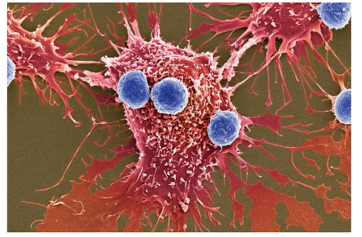

- 中医:望闻问切

- 西医:各种设备，检查一通

- 无论中医还是西医

    - 获取指标、数据、特征

- 有一些微观数据，都是人体细胞内、血液中的数据、指标

- 设备越来越先进，获取更多微观数据、指标、特征

- 有一些病，先微观，后宏观(感觉不舒服)



算法建模:

- IKNN算法建模构建微观数据和疾病之间的关系

- KNN调整超参数，准确率提升

- 数据归一化、标准化，提升更加明显

算法实战:

- 导包



## 5.1.1、加载数据

In [1]:
import numpy as np

import pandas as pd

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split

from sklearn.model_selection import GridSearchCV

In [2]:
data = pd.read_csv('./cancer.csv', sep='\t')
data.head()

,ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,2,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,3,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,4,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,5,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
y = data['Diagnosis']

X = data.iloc[:,2:]

display(X.head(), y.head())

,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


0    0
1    0
2    0
3    0
4    0
Name: Diagnosis, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
random_state=100)
display(X_train.shape,X_test.shape)

(455, 30)

(114, 30)

## 5.1.2、网络搜索超参数

In [5]:
%%time
estimator=KNeighborsClassifier()

params = dict(n_neighbors = np.arange(1, 30),
weights = ['uniform','distance'], p = [1,2])

gCV=GridSearchCV(estimator, params, cv = 6, scoring='accuracy')
gCV.fit(X_train,y_train)

CPU times: total: 23.7 s
Wall time: 7.9 s


GridSearchCV(cv=6, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]),
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='accuracy')

## 5.1.3、查看GridSearchCV最佳的参数组合

In [6]:
gCV.best_score_

np.float64(0.9384210526315789)

In [7]:
gCV.best_params_

{'n_neighbors': np.int64(10), 'p': 1, 'weights': 'uniform'}

In [8]:
model = gCV.best_estimator_
model

KNeighborsClassifier(n_neighbors=np.int64(10), p=1)

## 5.1.4、模型预测

In [9]:
y_pred = model.predict(X_test)
print('算法预测值:',y_pred[:20])

算法预测值: [0 1 0 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 1 1]


In [10]:
print("真实数据是:\n",y_test[:20])

真实数据是:
 400    0
225    1
321    0
173    1
506    1
380    1
197    0
260    0
40     0
160    1
391    1
417    0
265    0
254    0
308    1
184    0
54     0
267    1
103    1
142    1
Name: Diagnosis, dtype: int64


In [11]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.956140350877193

In [12]:
(y_test == y_pred).mean()

np.float64(0.956140350877193)

In [13]:
model.score(X_test, y_test)

0.956140350877193

In [14]:
gCV.score(X_test, y_test)

0.956140350877193

## 5.1.5、归一化利器

- 归一化(Normalization)是一种数据预处理方法，用于将数据缩放到一个统一的范围，通常是[0,1]或[-1,1]。

以下是两种最常用的归一化方法：

1. 方式一， Min-Max归一化(线性缩放):Min-Max归一化将原始数据线性缩放到[0,1]的范围。对于给定的一组数据x，Min-Max归一化的计算公式为:

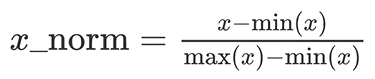

In [15]:
# 方式一
from sklearn.preprocessing import MinMaxScaler

In [16]:
mms = MinMaxScaler()
X_norml =mms.fit_transform(X)
X_norml

array([[0.0226581 , 0.54598853, 0.36373277, ..., 0.59846245, 0.41886396,
        0.        ],
       [0.27257355, 0.61578329, 0.50159067, ..., 0.23358959, 0.22287813,
        0.        ],
       [0.3902604 , 0.59574321, 0.44941676, ..., 0.40370589, 0.21343303,
        0.        ],
       ...,
       [0.62123774, 0.44578813, 0.30311771, ..., 0.12872068, 0.1519087 ,
        0.        ],
       [0.66351031, 0.66553797, 0.4757158 , ..., 0.49714173, 0.45231536,
        0.        ],
       [0.50152181, 0.02853984, 0.01590668, ..., 0.25744136, 0.10068215,
        1.        ]])

In [17]:
X_train, X_test,y_train,y_test = train_test_split(X_norml, y, test_size=0.2, random_state=100)

In [18]:
estimator =KNeighborsClassifier()

params =dict(n_neighbors = np.arange(1,30), weights = ['uniform', 'distance'], p = [1,2])

gCV=GridSearchCV(estimator, params, cv = 6, scoring = 'accuracy')
gCV.fit(X_train,y_train) # 训练


GridSearchCV(cv=6, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]),
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [19]:
print("超参数:",gCV.best_params_)

score = gCV.score(X_test,y_test)
print("Min-Max归一化数据，模型得分是:", score)

超参数: {'n_neighbors': np.int64(1), 'p': 2, 'weights': 'uniform'}
Min-Max归一化数据，模型得分是: 1.0


方式二，z-Score归一化(标准化)：Z-Score归一化将原始数据转换为均值为0，标准差为1的标准正态分布。

对于给定的一组数据x，Z-Score归一化的计算公式为:

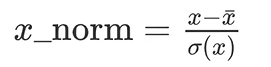

其中，表示数据集的均值，σ(x)表示数据集的标准差。

In [20]:
# 方式二
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_norm2 = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_norm2, y, test_size=0.2, random_state=100)

estimator=KNeighborsClassifier()

params = dict(n_neighbors = np.arange(1,30),

weights = ['uniform', 'distance'],

p =[1,2])

gCV = GridSearchCV(estimator, params, cv = 6, scoring='accuracy')
gCV.fit(X_train,y_train) #训练

print("超参数:",gCV.best_params_) 

score = gCV.score(X_test,y_test)

print('z-Score标准化数据，模型得分是:',score)

超参数: {'n_neighbors': np.int64(10), 'p': 2, 'weights': 'uniform'}
z-Score标准化数据，模型得分是: 1.0
